In [1]:
library(survival)
library(survminer)
library(openxlsx)
library(readxl)
library(tidyverse)
library(survival) 
library(GGally)
library(tidyverse)
library(mlr3)
library(mlr3pipelines)
library(mlr3verse)
library(mlr3proba)
library(mlr3extralearners)
library(glmnet)
library(data.table)
library(splines)
library(ranger)
library(precrec)
library(cowplot)

Loading required package: ggplot2

Loading required package: ggpubr


Attaching package: ‘survminer’


The following object is masked from ‘package:survival’:

    myeloma


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ lubridate 1.9.3     ✔ tibble    3.3.1
✔ purrr     1.2.1     ✔ tidyr     1.3.2
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Registered S3 method overwritten by 'GGally':
  method from   
  +.gg   ggplot2

Loading required package: Matrix


Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack


Loaded glmnet 4.1-8


Attaching package: ‘data.table’


The following objects are masked from ‘p

# Load model

In [2]:
Trained_Surv.EN = readRDS("Trained_Surv.EN.rds")
Trained_Surv.coxph = readRDS("Trained_Surv.coxph.rds")
Trained_Surv.Ranger = readRDS("Trained_Surv.Ranger.rds")
Trained_Surv.xgba = readRDS("Trained_Surv.xgba.rds")

In [3]:
learner = Trained_Surv.coxph
learner

<GraphLearner:Surv.coxph>
* Model: graph_learner_model
* Parameters: imputelearner.xval=0, scalerange.lower=0,
  scalerange.upper=1, scalerange.affect_columns=<Selector>
* Validate: NULL
* Packages: mlr3, mlr3pipelines, graphics, mlr3proba, survival, distr6
* Predict Types:  [crank], distr, lp, response
* Feature Types: logical, integer, numeric, character, factor, ordered,
  POSIXct
* Properties: featureless, hotstart_backward, hotstart_forward,
  importance, loglik, marshal, missings, oob_error, selected_features,
  weights

# Load example data

In [4]:
Examples = readRDS('Example_data.rds')
Examples

surv_time,throm,Age,Anti.angiogenic.therapy,Antimetabolite,Antineoplastic.antibiotics,Bladder.ureter,Breast,DNA.topoisomerase.inhibitor,Esophagus,⋯,Microtubule.inhibitor,Nutrition,Ovarian.fallopianTube,PICC,PORT,Platinum,Stage.III,Stage.IV,Thrombosis.history,Uterine.vagina
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
107,0,64,0,0,0,0,0,1,0,⋯,0,1,0,0,0,0,0,1,0,0
111,0,43,0,0,0,0,0,0,0,⋯,1,0,0,0,0,1,1,0,0,0
66,1,48,0,0,1,0,1,0,0,⋯,1,0,0,0,0,0,0,0,0,0


# Model usage

In [5]:
Examples_task = as_task_surv(Examples, time='surv_time',event='throm',type = "right")

Examples_task_op = learner$predict(Examples_task)

Examples_task_op$crank

1           2           3 
 0.13806430 -0.02756853  0.14967561

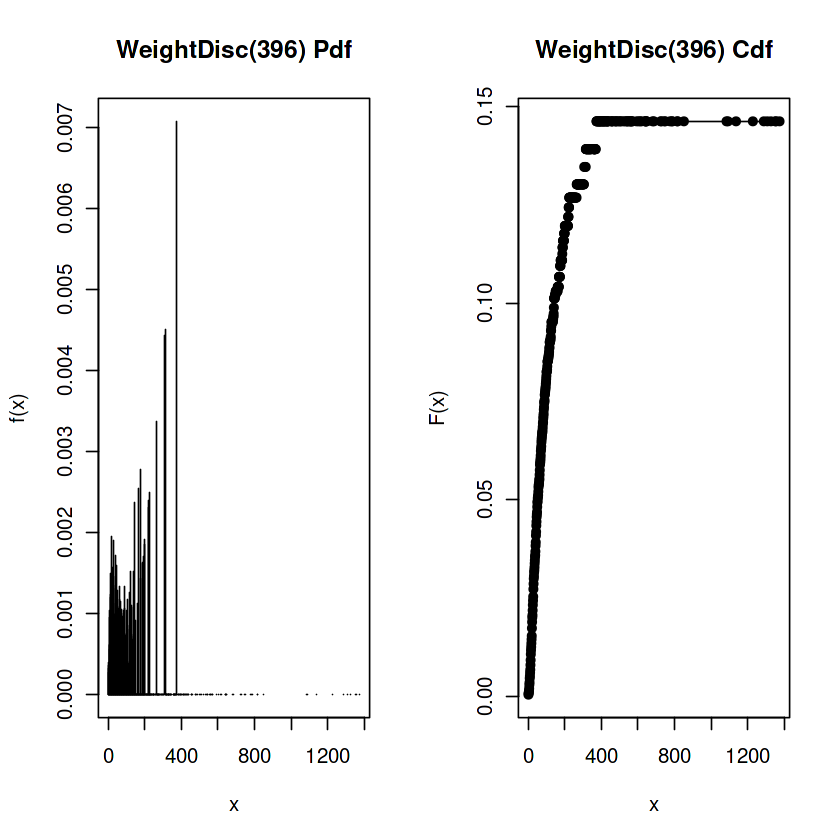

In [6]:
plot(Examples_task_op$distr[1])

# Visualize model output

In [7]:
get_t_cdf = function(plot_df, t) {
    plot_df30 = merge(data.frame(points = 1:max(plot_df$points)), plot_df, all.x = TRUE)# %>% dplyr::slice(1:365)
    plot_df30[is.na(plot_df30)] = 0
    plot_df30$cdf = cumsum(plot_df30$pdf)

    t_cdf = plot_df30$cdf[t]
    
    return(t_cdf)
}

In [8]:
target_cdf = seq(0.05, 1, by = 0.05)

In [9]:
get_plot = function(learner, data, expected_catheter_day) {
    data_task = as_task_surv(data, time='surv_time',event='throm',type = "right")
    data_task_op = learner$predict(data_task)
    distr = data_task_op$distr[1]
    crank = data_task_op$crank[1]
    
    plot_df = plot(distr) %>% as.data.frame() %>% dplyr::slice(1:365)
    plot_df3 = merge(data.frame(points = 1:max(plot_df$points)), plot_df, all.x = TRUE) %>% dplyr::slice(1:365)
    summary(plot_df3$points)
    plot_df3[is.na(plot_df3)] = 0
    plot_df3$Scaled = plot_df3$points# - 1
    
    plot_den3 = plot_df3 %>% select(c(Scaled, pdf)) %>% 
        ggplot(., aes(x=Scaled, weight = pdf)) + 
        geom_histogram(aes(y = ..density..), bins = nrow(plot_df3), fill = "blue", alpha = 0.5) +
        theme_classic() + theme(text = element_text(size= 15), axis.text = element_blank()) +
      labs(
        x = "Days",
        y = "Probablity"
      )
    
    #Fitting curve
    plot_den3 = plot_df3 %>% select(c(Scaled, pdf)) %>% 
        ggplot(., aes(x=Scaled, weight = pdf)) + 
        geom_histogram(aes(y = ..density..), bins = nrow(plot_df3), fill = "blue", alpha = 0.2) +
        geom_density(color = "blue", size = 1, kernel = 'gaussian', bw = 3) + 
        theme_classic() + theme(text = element_text(size= 15), axis.text = element_blank()) +
      labs(
        x = "Days",
        y = "Probablity"
      )
    den3_df = ggplot_build(plot_den3)$data[[2]]
    max_p = max(den3_df$density[1:180])
    max_p_day = den3_df$x[1:180][which(den3_df$density[1:180] == max_p)][1]
    half_p = max_p/2
    larger_days = den3_df$x[which(den3_df$y > half_p)]#[1]
    cut_day = ifelse(length(larger_days)!=0,larger_days[1],365)
    cut_day
    small_days = den3_df$x[which(den3_df$y < half_p)]#[1]
    cut_last_day = ifelse(length(small_days)!=0,small_days[which(small_days > max_p_day)[1]], 365+1)
    cut_last_day

    #Calculating cumulative
    plot_df30 = merge(data.frame(points = 1:max(plot_df$points)), plot_df, all.x = TRUE)
    plot_df30[is.na(plot_df30)] = 0
    #calculate cdf
    plot_df30$cdf = cumsum(plot_df30$pdf)
    plot_df30$Scaled = plot_df30$points
    #Find the probability of the expected catheter days
    cumulative_risk_used = plot_df30$cdf[expected_catheter_day]
    cum_y_pos = max(plot_df30$pdf)
    #Calculating cumulative by 0.05 segmentation
    target_cdf <- seq(0.05, 1, by = 0.05)
    cumu_05_points = map_dbl(target_cdf[which(target_cdf <= max(plot_df30$cdf))], function(x){
                                plot_df30[which(plot_df30$cdf >= x)[1],'points']
                            })

    label_dots30 = data.frame(x = cumu_05_points, 
                               y = target_cdf[which(target_cdf <= max(plot_df30$cdf))], 
                               label = as.character(cumu_05_points))

    target_df = data.frame(yintercept = target_cdf)
    plot_den30 = plot_df30 %>% select(c(Scaled, cdf)) %>% 
        ggplot(., aes(y = cdf, x=Scaled)) + 
        geom_line(color = "#5C5D9E", size = 1, alpha = 1) +
        geom_hline(data = target_df, aes(yintercept = yintercept), linetype = "dashed", color = "black", size = 1, alpha = 0.3) +
        geom_point(data = label_dots30, aes(x = x, y = y), color = "red", size = 1.5) + 
        geom_text(data = label_dots30, aes(x = x, y = y, label = label), color = "black", vjust = -0.5, size = 3) +
        theme_classic() + theme(text = element_text(size= 18)) +
        coord_cartesian(xlim = c(0, 365), ylim = c(0, max(plot_df30$cdf))) +
        labs(
            x = "Days",
            y = "cumulative probability",
        ) + theme(plot.title = element_text(
          face = "bold",
          size = 12,
        ), text = element_text(size= 12))

    
    cumu_05_points = ifelse(max(plot_df30$cdf) < 0.05, 'No need', 
                            paste(map_dbl(target_cdf[which(target_cdf <= max(plot_df30$cdf))], function(x){
                                plot_df30[which(plot_df30$cdf >= x)[1],'points']
                            }), collapse= ', '))
    label_dots = data.frame(x = c(cut_day, max_p_day, cut_last_day, expected_catheter_day), 
                               y = c(half_p, max_p, half_p, cum_y_pos), 
                               label = c(paste('t1', '\n', round(cut_day,0), sep = ''),
                                         paste('Highest', '\n', round(max_p_day,0), sep = ''),
                                         paste('t2', '\n', round(cut_last_day,0), sep = ''), 
                                         paste('Cumulative', '\n', round(cumulative_risk_used,3), sep = '')))
    
    plot_den3 = plot_df3 %>% select(c(Scaled, pdf)) %>% 
        ggplot(.) + 
        geom_histogram(aes(y = ..density.., x=Scaled, weight = pdf), bins = nrow(plot_df3), fill = "blue", alpha = 0.2) +
        geom_density(aes(x=Scaled, weight = pdf), color = "blue", size = 1, kernel = 'gaussian', bw = 3) + 
        geom_vline(xintercept = cut_day, linetype = "dashed", color = "black", size = 1, alpha = 0.5) +
        geom_vline(xintercept = cut_last_day, linetype = "dashed", color = "black", size = 1, alpha = 0.5) +
        geom_point(data = label_dots, aes(x = x, y = y), color = "red", size = 1.5) + 
        geom_text(data = label_dots, aes(x = x, y = y, label = label), color = "black", vjust = -0.5, size = 3) +
        geom_vline(xintercept = expected_catheter_day, linetype = "solid", color = "#5AAA46", size = 1) +
        theme_classic() + theme(text = element_text(size= 12)) +
        coord_cartesian(xlim = c(0, 365)) +
        labs(
            title = paste(
                          'High risk period = ', round(cut_day,0), ' - ', round(cut_last_day,0), 'day (Max', round(max_p_day,0), 'day)', '\n',
                          sep = ''
                         ),
            x = "Days",
            y = "instantaneous probability"
        ) + theme(plot.title = element_text(
          face = "bold",
          size = 12,
        ), text = element_text(size= 12))
    
    plot_grid(plot_den3, plot_den30, ncol = 1, rel_heights = c(6, 4))
}

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”
Warning message:
“The dot-dot notation (`..density..`) was deprecated in ggplot2 3.4.0.
ℹ Please use `after_stat(density)` instead.”


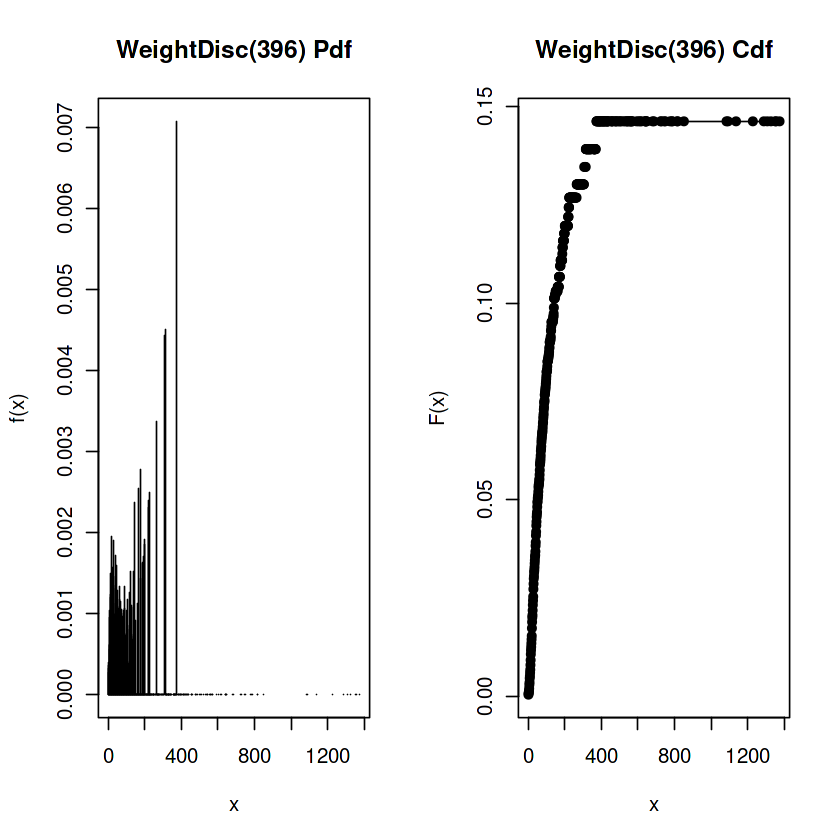

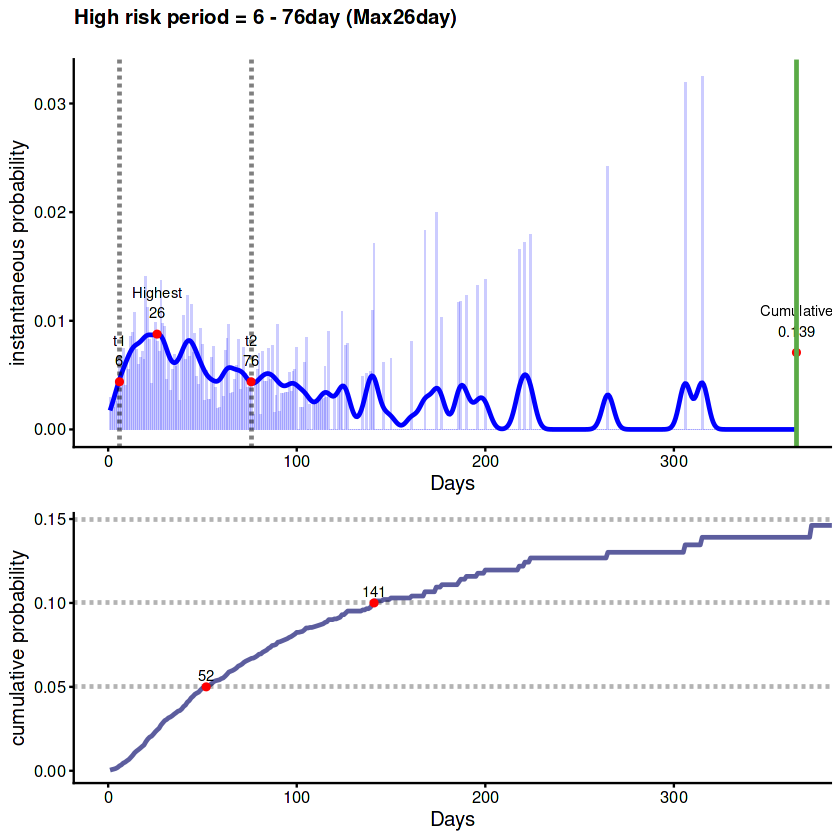

In [10]:
get_plot(learner, Examples[1,], 365)